# Pad Centroid Distance

## Geometry Analysis
This notebook calculates the distance between the centroids of pads. Centroid is the center of mass of an triangle pad. As the small pads' side length ($a$) is 4.9, we expect the closest distance of two small pads are $4.9/\sqrt{3} = 2.83$, then $4.9$, $4.9*2\sqrt{3} = 5.66$...

We show the probable distances between same (different) size pads in FIG.1 (FIG.2).

![FIG.1](../../../assets/mapping/same-pads.png)

FIG.1: Distance between same size pads. (a) Red pad is the reference pad, 3 orange pads are the closest pads, then 6 green pads, 3 blue pads. (b) Distance (black line) between orange pad and red pad is $a/\sqrt{3}$, where $a$ is the side length of pad; (c) Distance between green pad and red pad is $a$; (d) Distance between blue pad and red pad is $2a/\sqrt{3}$.

In FIG.1(b), black line, red dashed line and orange dashed line are in an equilaterial triangle, then the length of black line equals to the dahsed lines. In FIG.1(c), black line is parellel to orange side, forming a rectangle with red dashed line and green dashed line, and the length equals to the orange side. In FIG.1(d), black line equals to red dashed line plus blue dashed line.

As the result, we expect the closest distance of two small pads are 2.83, 4.9, then 5.66, with the ratio 1:2:1. Similarly, the expected closest distance of two large pads should be 5.66, 9.8, 11.32, 12.84, with ratio 1:2:1

![FIG.2](../../../assets/mapping/different-pads.png)

FIG.2: Distance between different size pads. (a) Left red pad is the reference large pad, 2 orange pads are the closest pads, then 1 green pads, 2 blue pads (only 1 drawn), 1 purple pad. (b) Distance (black line) between orange pad and red pad is $a$, where $a$ is the side length of pad; (c) Distance between green pad and red pad is $2a/\sqrt{3}$; (d) Distance between blue pad and red pad is $\sqrt{7}a/\sqrt{3}$; (e) Distance between purple pad and red pad is $\sqrt{3}a$. (e), (f) Distances from right red pad are similar to the left red pads.

For FIG.2(b) and FIG.2(d), the length of black line are calculated by law of cosine, as we know the length of red dashed line and orange (blue) dashed line, and the angle between them is 60 (120) degrees. For FIG.2(c) and FIG.2(e), black line equals to the red dashed line plus green (should be blue, but for some reason I draw it as green in FIG.2(e) and explain below) dashed line.

When we consider the right red pad as the reference, the distances are similar to the left red pad as shown in FIG.2(e) and (f). So I render triangles in FIG.2(e) and (f) only in red and green. In each subfigure, the distance between green pads is equal to the red pads. For example, in FIG.2(f), two green pads are actually the red pad and blue pad in FIG.2(d) with distance $\sqrt{7}a/\sqrt{3}$. And the red pads in FIG.2(f) are green pads with rotation. So the distance of red pads in FIG.2(f) is also $\sqrt{7}a/\sqrt{3}$, which is the closest distance for the right red pad in FIG.2(a). In short, the closest distance of right red pad in FIG.2(a) is $\sqrt{7}a/\sqrt{3}$ (with the right orange pad and purple pad). The distance between right red pad and blue pad seems closer, but it's actually $\sqrt{3}a$ larger than $\sqrt{7}a/\sqrt{3}$.

As the result, we expect the closest distance of large pad and small pad are 4.9, 5.66, 7.48, with ratio 2:1:4. Where 2 is from two orange pads and left red pad; 1 is from  green pad and left red pad; 4 is from two blue pads (only 1 drawn) and left red pad, right orange pad and right red pad, and purple pad and right red pad.

The closest distance of pads are summarized in TABLE.

| Pad Pair Size | 1st distance | 2nd distance | 3rd distance | Ratio |
| ------------- | ------------ | ------------ | ------------ | ----- |
| Small-Small   | 2.83         | 4.9          | 5.66         | 1:2:1 |
| Large-Large   | 5.66         | 9.8          | 11.32        | 1:2:1 |
| Small-Large   | 4.9          | 5.66         | 7.48         | 2:1:4 |

## Code Implementation

We first still import libraries and read pads data.

In [3]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

%matplotlib widget

figs = [None]*4
pads = pl.read_csv("../../../src/attpc_estimator/detector/pads.csv").select(["pad", "cx", "cy", "scale"])
print(
	f"Pads {len(pads)}, "
	f"small pads {len(pads.filter(pl.col("scale") == 0.5))}, "
	f"large pads {len(pads.filter(pl.col("scale") == 1))}."
)


Pads 10240, small pads 6144, large pads 4096.


Then we calculate the distance matrix, and convert them into iterable array.

In [4]:
distance_matrix = (
	pads
	.join(pads, how="cross")
	.filter(pl.col("pad") < pl.col("pad_right"))
	.select(
		"pad",
		"pad_right",
		(
			(
				(pl.col("cx") - pl.col("cx_right"))**2
				+ (pl.col("cy") - pl.col("cy_right"))**2
			)**0.5
		).alias("distance"),
		(pl.col("scale") + pl.col("scale_right")).alias("scale_sum")
	)
	.group_by("pad")
	.agg(pl.all().sort_by("distance").head(12))
	.sort("pad")
	.explode(["pad_right", "distance", "scale_sum"])
)
small_small_distances = (
	distance_matrix.filter(pl.col("scale_sum") == 1).select(pl.col("distance"))
)
small_large_distances = (
	distance_matrix.filter(pl.col("scale_sum") == 1.5).select(pl.col("distance"))
)
large_large_distances = (
	distance_matrix.filter(pl.col("scale_sum") == 2).select(pl.col("distance"))
)

We first plot distance between small pads.

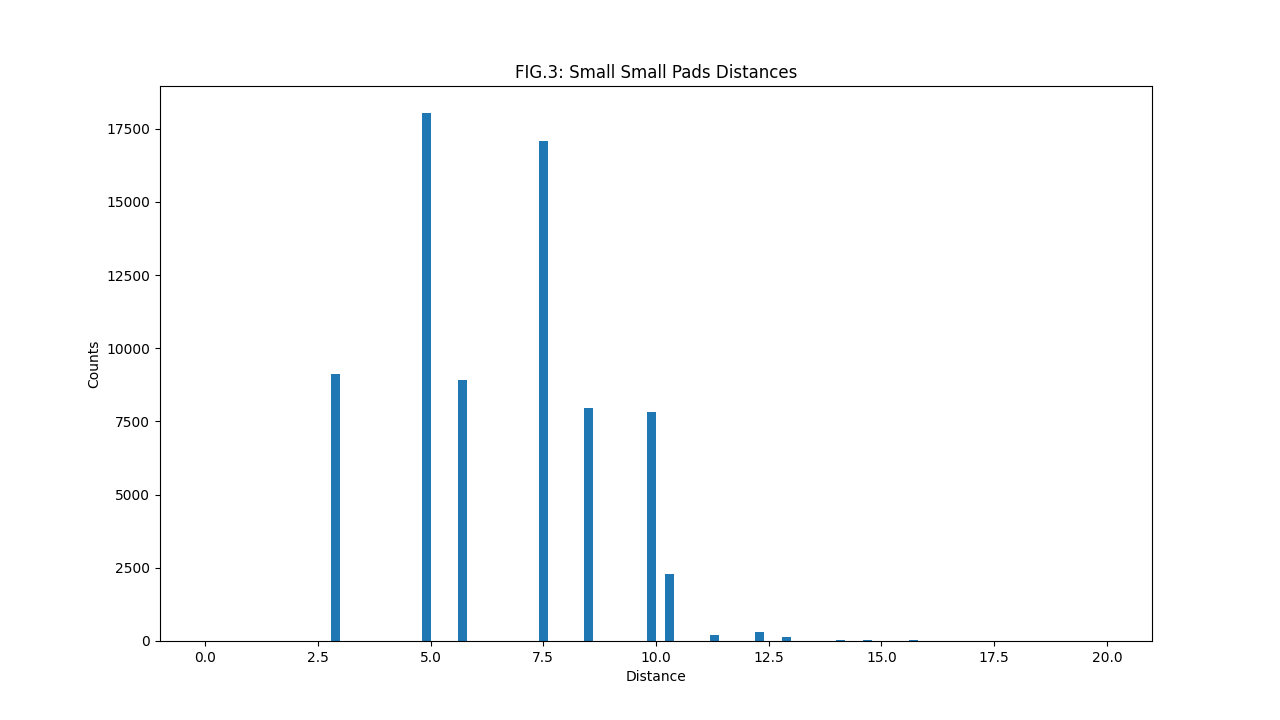

In [5]:
if figs[0] is not None:
	plt.close(figs[0])
figs[0], ax = plt.subplots(1, 1, figsize=(12.8, 7.2))
ax.hist(small_small_distances, bins=100, range=(0, 20))
ax.set_title("FIG.3: Small Small Pads Distances")
ax.set_xlabel("Distance")
ax.set_ylabel("Counts")
plt.show()


We have 6144 small pads, for each small pad, there are 3 closest small pads. We expect 6144*3/2 = 9216 closest distances at about 2.83. We got about 9000 from FIG.3, which is close to the expected value. The differences may come from the pads at the edge closing to the large pads.

And, for the second closest distances, we expect 6144*6/2 = 18432 distances at about 4.9, then also counts for 9216 for the third closest distances at 5.66. All these are similar to FIG.3.

Be careful that we only pick the closest 12 distances for each pad, so the counts for distances over 5.66 in FIG.3 may not be accurate and less than expected.

Next, we plot distance between large pads.

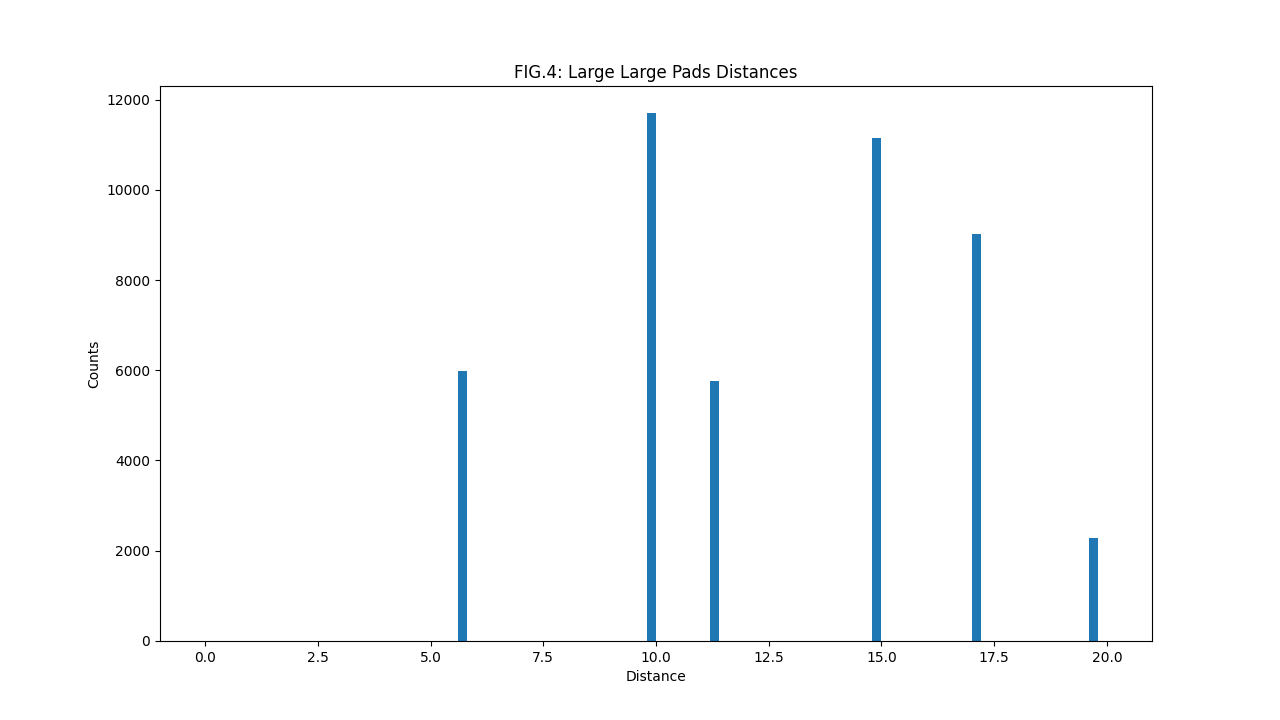

In [6]:
if figs[1] is not None:
	plt.close(figs[1])
figs[1], ax = plt.subplots(1, 1, figsize=(12.8, 7.2))
ax.hist(large_large_distances, bins=100, range=(0, 20))
ax.set_title("FIG.4: Large Large Pads Distances")
ax.set_xlabel("Distance")
ax.set_ylabel("Counts")
plt.show()


As expected, distances of large pads shown in FIG.4 is similar to the distances of small pads shown in FIG.3, which scales 2 at x axis and scales 4096/6144=0.67 at y axis.

At last, it's the distance between small pads and large pads. They should be located at the edge of small pads and large pads.

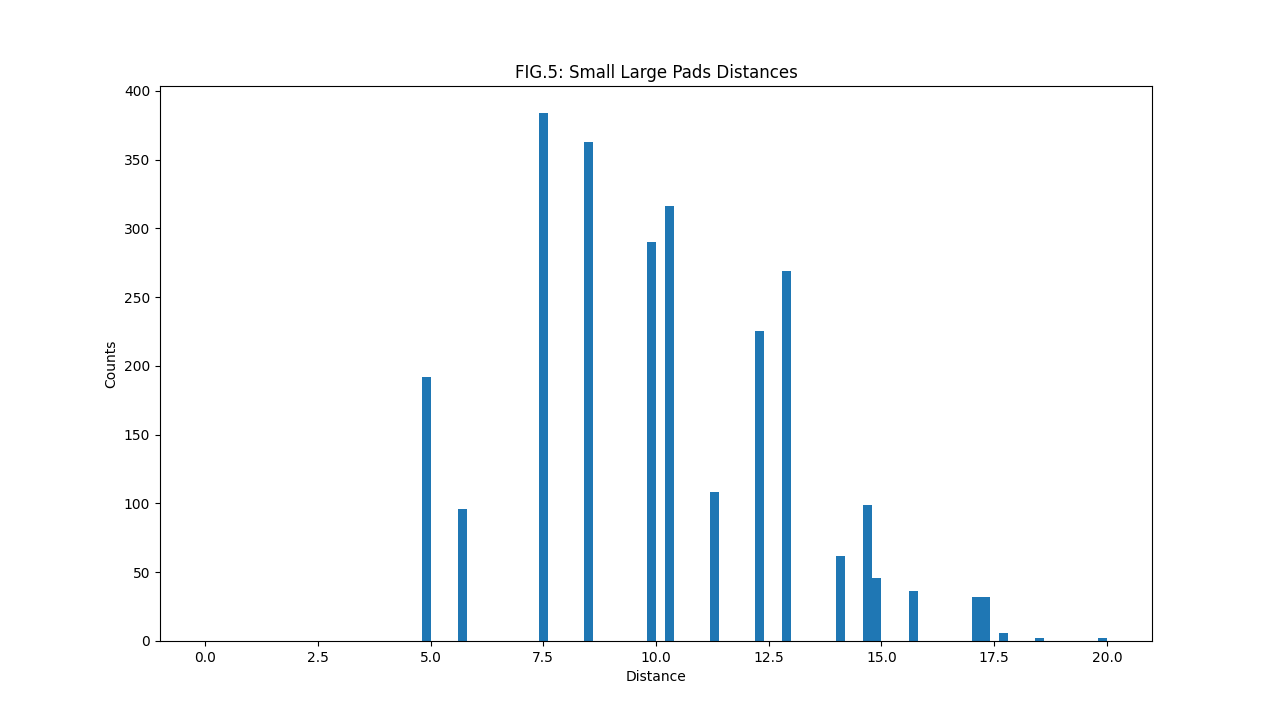

In [7]:
if figs[2] is not None:
	plt.close(figs[2])
figs[2], ax = plt.subplots(1, 1, figsize=(12.8, 7.2))
ax.hist(small_large_distances, bins=100, range=(0, 20))
ax.set_title("FIG.5: Small Large Pads Distances")
ax.set_xlabel("Distance")
ax.set_ylabel("Counts")
plt.show()


The ratio of 4.9, 5.7 and 7.5 is about 2:1:4, as the expect one.

## Summary
The ratio and counts of pad distances are as expected.